# Classification notebook: Logisitc Regression, KNN, and NB

In [36]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())
from minilearn.helper import ezcols
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.preprocessing.Scaler import StandardScalerMM


Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


In [37]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


In [38]:
feature_cols = ezcols()

X = features[feature_cols]
y = features["emotion"]

print(X.shape)
print(y.value_counts())

(2451, 480)
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
surprised    192
disgust      191
neutral      188
Name: count, dtype: int64


Very suspicious results. Down below I did the same thing you do before every model. Just copy and pasted from previous notebook. However I am getting a higher accuracy then the SK learn model. Which means mine is probably broken. Okay figured it out, seems like my model is not running as many iterations. Close to only 1000 so the accuracy is higher then SK-learn. When increased it becomes close to the actual logistic regression code.

In [41]:
from sklearn.linear_model import LogisticRegression
from minilearn.classifiers.logisiticRegressionFunc import LogisticRegressionMM
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, shuffle=True
)

scaler = StandardScalerMM()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

skimodel = LogisticRegression(max_iter=2000)
minilearnmodel = LogisticRegressionMM(n_iters=2000)

skimodel.fit(X_train_scaled, y_train)
minilearnmodel.fit(X_train_scaled, y_train)

ski_pred = skimodel.predict(X_test_scaled)
mini_pred = minilearnmodel.predict(X_test_scaled)

print("MiniLearn train accuracy:", minilearnmodel.score(X_train_scaled, y_train))
print("MiniLearn test accuracy:", minilearnmodel.score(X_test_scaled, y_test))

print("Sklearn train accuracy:", skimodel.score(X_train_scaled, y_train))
print("Sklearn test accuracy:", skimodel.score(X_test_scaled, y_test))




(1961, 480)
(490, 480)
MiniLearn train accuracy: 0.96838347781744
MiniLearn test accuracy: 0.7163265306122449
Sklearn train accuracy: 0.9994900560938297
Sklearn test accuracy: 0.689795918367347


Sklearn Logistic Regression
Accuracy: 0.689795918367347
Precision macro: 0.6917130463292929
Recall macro: 0.6874536141851535
F1 macro: 0.6892849735666409
F1 weighted: 0.6897399242909856
ROC AUC macro: 0.9428914512675897


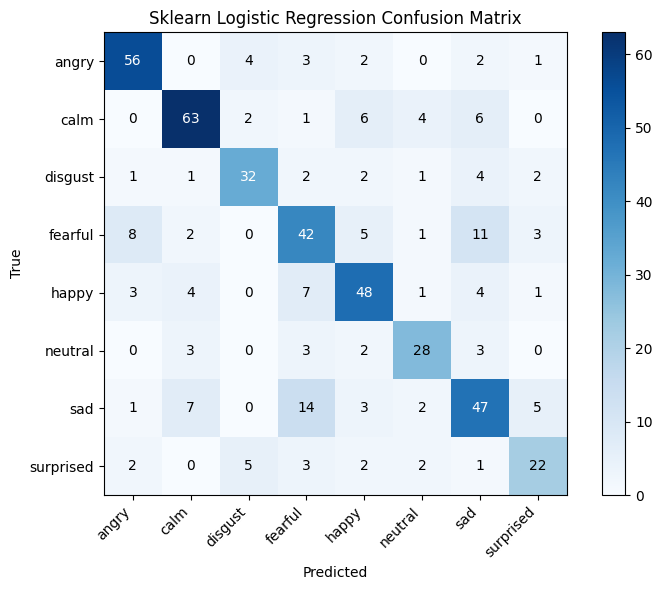

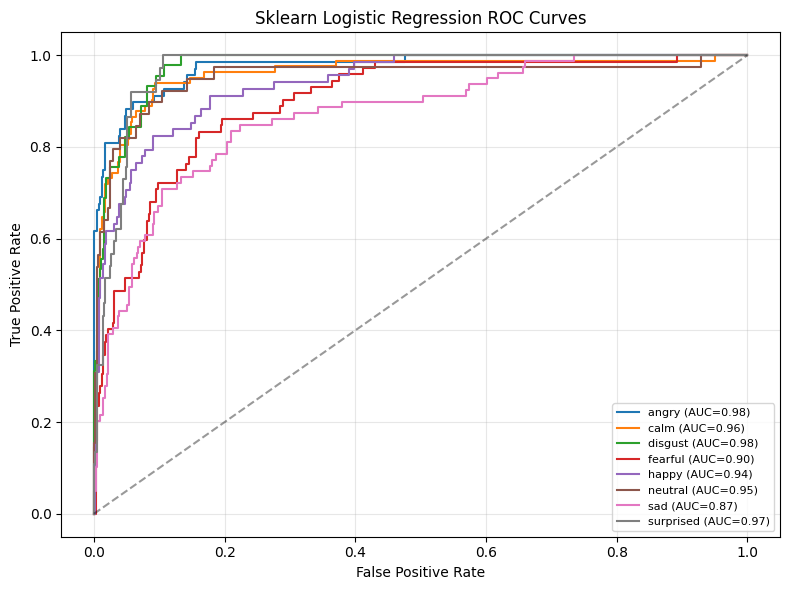

MiniLearn Logistic Regression
Accuracy: 0.6959183673469388
Precision macro: 0.6949431432695385
Recall macro: 0.6937302891469028
F1 macro: 0.6934513393400674
F1 weighted: 0.6940774628236638
ROC AUC macro: 0.9463740132786796


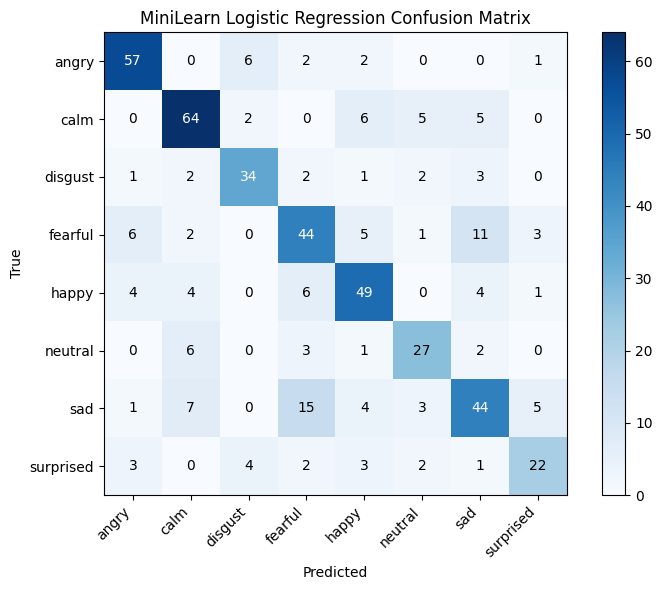

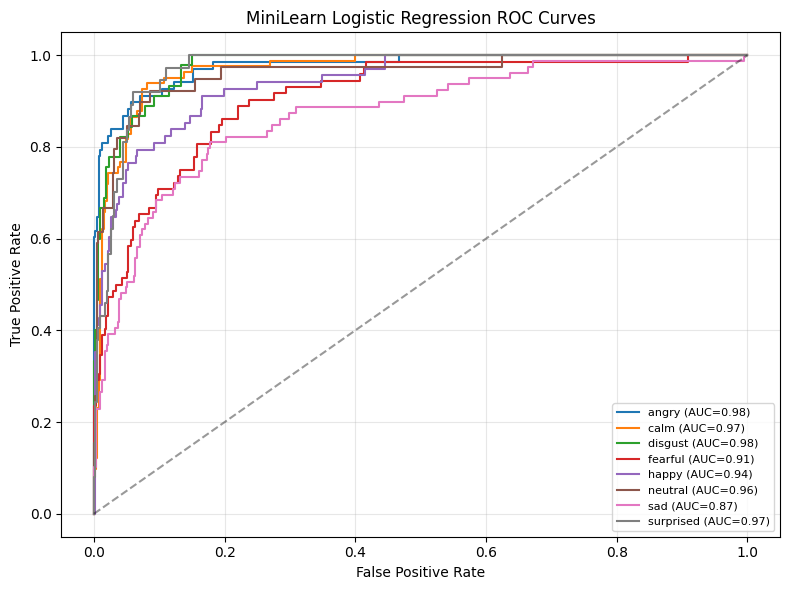

In [40]:
from minilearn.metrics.metricss import (
    accuracy,
    confusion_matrix,
    precision,
    recall,
    f1_score,
    roc_auc,
    plot_confusion_matrix,
    plot_roc_curves
)

labels = list(minilearnmodel.classes)
class_names = labels

ski_pred = skimodel.predict(X_test_scaled)
mini_pred = minilearnmodel.predict(X_test_scaled)

ski_proba = skimodel.predict_proba(X_test_scaled)
mini_proba = minilearnmodel.predict_proba(X_test_scaled)

for model_name, preds, proba in [
    ("Sklearn Logistic Regression", ski_pred, ski_proba),
    ("MiniLearn Logistic Regression", mini_pred, mini_proba)
]:
    print("=" * 50)
    print(model_name)
    print("Accuracy:", accuracy(y_test, preds))
    print("Precision macro:", precision(y_test, preds, labels))
    print("Recall macro:", recall(y_test, preds, labels))
    print("F1 macro:", f1_score(y_test, preds, labels))
    print("F1 weighted:", f1_score(y_test, preds, labels, average="weighted"))
    print("ROC AUC macro:", roc_auc(y_test, proba, labels))
    cm = confusion_matrix(y_test, preds, labels)
    plot_confusion_matrix(cm, class_names, title=f"{model_name} Confusion Matrix")
    plot_roc_curves(y_test, proba, labels, class_names, title=f"{model_name} ROC Curves")

# KNN vs sickit learn

In [45]:
from minilearn.classifiers.KNN import KNNClassifierMM
from sklearn.neighbors import KNeighborsClassifier 


skimodelKNN = KNeighborsClassifier(n_neighbors=5)
minilearnmodelKNN = KNNClassifierMM(k=5)

skimodelKNN.fit(X_train_scaled, y_train)
minilearnmodelKNN.fit(X_train_scaled, y_train)

ski_pred_KNN = skimodelKNN.predict(X_test_scaled)
mini_pred_KNN = minilearnmodelKNN.predict(X_test_scaled)

print("MiniLearn train accuracy:", minilearnmodelKNN.score(X_train_scaled, y_train))
print("MiniLearn test accuracy:", minilearnmodelKNN.score(X_test_scaled, y_test))

print("Sklearn train accuracy:", skimodelKNN.score(X_train_scaled, y_train))
print("Sklearn test accuracy:", skimodelKNN.score(X_test_scaled, y_test))

MiniLearn train accuracy: 0.8041815400305966
MiniLearn test accuracy: 0.5816326530612245
Sklearn train accuracy: 0.8041815400305966
Sklearn test accuracy: 0.5816326530612245


Sklearn K-Nearest-Neighbors
Accuracy: 0.5816326530612245
Precision macro: 0.574331339055296
Recall macro: 0.5620209448619066
F1 macro: 0.5574173851626689
F1 weighted: 0.5654073182966346
ROC AUC macro: 0.8946843851327021


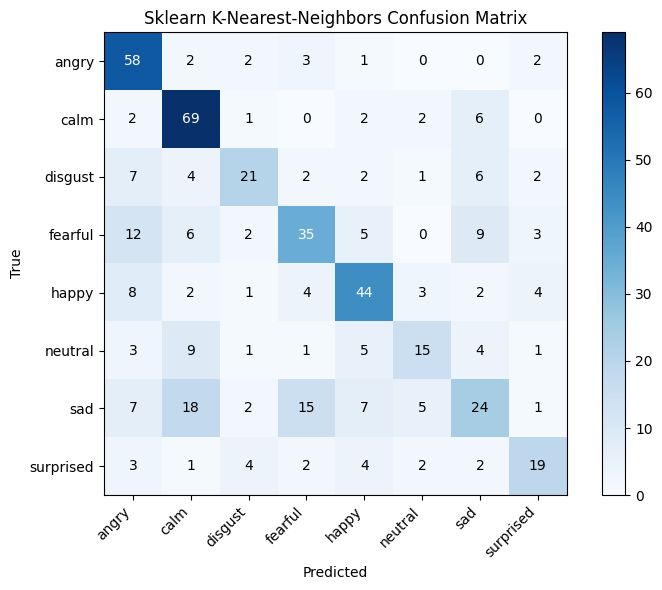

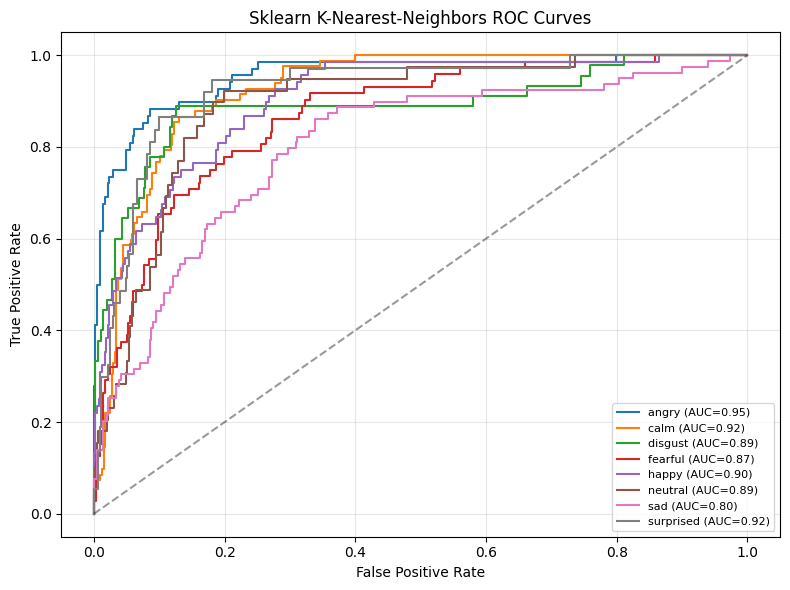

MiniLearn K-Nearest-Neighbors
Accuracy: 0.5816326530612245
Precision macro: 0.574331339055296
Recall macro: 0.5620209448619066
F1 macro: 0.5574173851626689
F1 weighted: 0.5654073182966346
ROC AUC macro: 0.8946843851327021


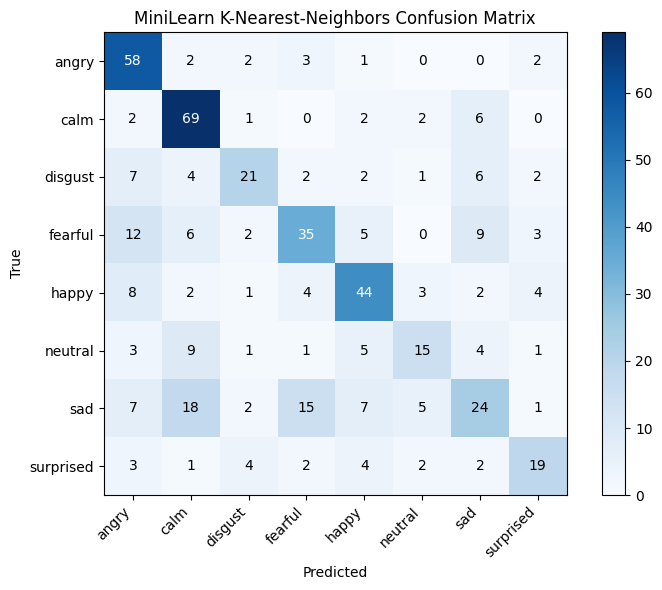

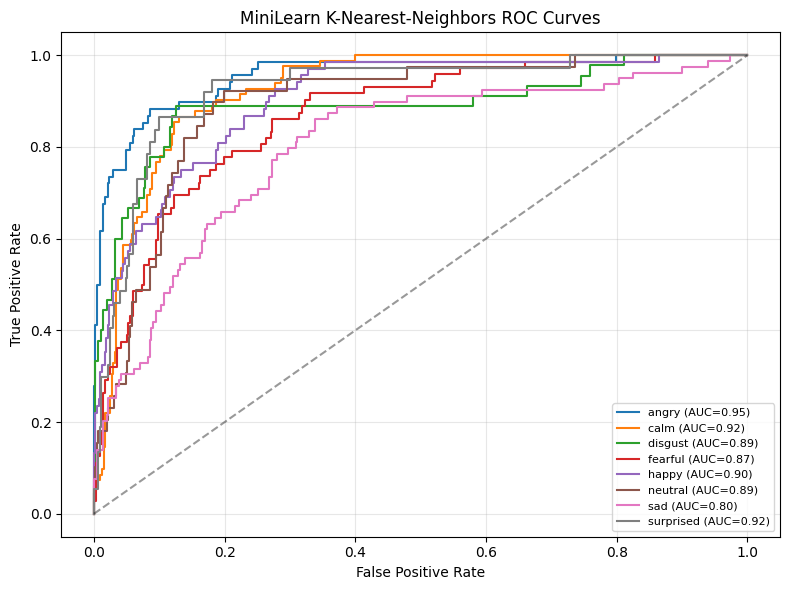

In [47]:
ski_proba_KNN = skimodelKNN.predict_proba(X_test_scaled)
mini_proba_KNN = minilearnmodelKNN.predict_proba(X_test_scaled)

for model_name, preds, proba in [
    ("Sklearn K-Nearest-Neighbors", ski_pred_KNN, ski_proba_KNN),
    ("MiniLearn K-Nearest-Neighbors", mini_pred_KNN, mini_proba_KNN)
]:
    print("=" * 50)
    print(model_name)
    print("Accuracy:", accuracy(y_test, preds))
    print("Precision macro:", precision(y_test, preds, labels))
    print("Recall macro:", recall(y_test, preds, labels))
    print("F1 macro:", f1_score(y_test, preds, labels))
    print("F1 weighted:", f1_score(y_test, preds, labels, average="weighted"))
    print("ROC AUC macro:", roc_auc(y_test, proba, labels))
    cm = confusion_matrix(y_test, preds, labels)
    plot_confusion_matrix(cm, class_names, title=f"{model_name} Confusion Matrix")
    plot_roc_curves(y_test, proba, labels, class_names, title=f"{model_name} ROC Curves")